#### Imports

In [176]:
import pandas as pd
import matplotlib.pyplot as plt

#### Import data

In [177]:
train = pd.read_csv('traindata_total.csv')
train = train.drop(columns = ['index', 'Service:RDT-ID'])
train.head()

,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,2025-12-01,Intercity,NS,1410,False,False,0,156552404,UT,Utrecht Centraal,2025-12-01T03:48:00+01:00,7.0,False,NaN,NaN,NaN,False,18.0,18.0
1,2025-12-01,Intercity,NS,1409,False,True,0,156552405,UT,Utrecht Centraal,NaN,NaN,NaN,2025-12-01T02:16:00+01:00,0.0,True,False,NaN,NaN
2,2025-12-01,Intercity,NS,1414,False,False,0,156552418,UT,Utrecht Centraal,2025-12-01T04:48:00+01:00,0.0,False,NaN,NaN,NaN,False,18.0,18.0
3,2025-12-01,Nightjet,NS Int,402,False,True,0,156552440,UT,Utrecht Centraal,2025-12-01T08:53:00+01:00,100.0,False,2025-12-01T08:55:00+01:00,100.0,False,False,14.0,14.0
4,2025-12-01,Intercity,NS,1413,False,False,26,156552444,UT,Utrecht Centraal,NaN,NaN,NaN,2025-12-01T03:16:00+01:00,7.0,False,False,18.0,18.0


#### Data cleaning

In [178]:
train.columns = train.columns.str.replace('Service:', '', regex=False)
train.columns = train.columns.str.replace('Stop:', '', regex=False)
train.columns = train.columns.str.replace('RDT-ID', 'train_id', regex=False)
train.columns = train.columns.str.replace('Arrival time', 'actual_arrival', regex=False)
train.columns = train.columns.str.replace('Departure time', 'actual_departure', regex=False)
train.columns = train.columns.str.replace('Arrival cancelled', 'arr_cancelled', regex=False)
train.columns = train.columns.str.replace('Departure cancelled', 'dep_cancelled', regex=False)
train.columns = train.columns.str.replace('Arrival delay', 'arr_delay', regex=False)
train.columns = train.columns.str.replace('Departure delay', 'dep_delay', regex=False)

cols_drop = ['Completely cancelled', 'Partly cancelled','Maximum delay','Train number', 'Station name', 'Station code','Platform change', 'Planned platform', 'Actual platform', 'Company']
cols_dt = ['actual_arrival', 'actual_departure']

train = train.drop(columns = cols_drop)
train[cols_dt] = train[cols_dt].apply(
    lambda col: pd.to_datetime(col, utc = True).dt.strftime('%H:%M')
)

In [179]:
# Convert actual arrival/departure times to datetime
train['actual_arrival'] = pd.to_datetime(
    train['actual_arrival'], format='%H:%M'
)

train['actual_departure'] = pd.to_datetime(
    train['actual_departure'], format='%H:%M'
)

# Calculate scheduled times by subtracting the delay
train['scheduled_arrival'] = (
    train['actual_arrival']
    - pd.to_timedelta(train['arr_delay'], unit='m')
)

train['scheduled_departure'] = (
    train['actual_departure']
    - pd.to_timedelta(train['dep_delay'], unit='m')
)

# Convert all time columns back to HH:MM
time_cols = [
    'actual_arrival',
    'actual_departure',
    'scheduled_arrival',
    'scheduled_departure'
]

train[time_cols] = train[time_cols].apply(
    lambda col: col.dt.strftime('%H:%M')
)

In [180]:
train.head()

,Date,Type,train_id,actual_arrival,arr_delay,arr_cancelled,actual_departure,dep_delay,dep_cancelled,scheduled_arrival,scheduled_departure
0,2025-12-01,Intercity,156552404,02:48,7.0,False,NaN,NaN,NaN,02:41,NaN
1,2025-12-01,Intercity,156552405,NaN,NaN,NaN,01:16,0.0,True,NaN,01:16
2,2025-12-01,Intercity,156552418,03:48,0.0,False,NaN,NaN,NaN,03:48,NaN
3,2025-12-01,Nightjet,156552440,07:53,100.0,False,07:55,100.0,False,06:13,06:15
4,2025-12-01,Intercity,156552444,NaN,NaN,NaN,02:16,7.0,False,NaN,02:09


In [202]:
missing_actuals = train[train['actual_arrival'].isna() & train['actual_departure'].isna()]

cols = ['train_id', 'actual_arrival', 'actual_departure'] # Also none only on train_id (all unique)
duplicates = train[train.duplicated(cols, keep=False)].sort_values(cols)


print(f"Number of duplicates found: {len(duplicates)}")
print(f"Number of trains with missing actual arrival or departure times: {len(missing_actuals)} (passing through station or data errors)")

Number of duplicates found: 0
Number of trains with missing actual arrival or departure times: 0 (passing through station or data errors)


In [181]:
# Initializing new variable to flag delay and delay with a three minute threshold
train['arrival_delayed'] = train['arr_delay'] > 0
train['departure_delayed'] = train['dep_delay'] > 0
train['arrival_delayed_3'] = train['arr_delay'] >= 3
train['departure_delayed_3'] = train['dep_delay'] >= 3

# Train is cancelled if either arrival or departure is cancelled. Fill NaN values with False for this.
train['cancelled'] = train['arr_cancelled'].fillna(False) | train['dep_cancelled'].fillna(False)

In [183]:
delayed_trains = (len(train[(train['arrival_delayed'] == True) | (train['departure_delayed'] == True)])) / len(train) * 100
delayed_operations = len(train[(train['arrival_delayed_3'] == True) | (train['departure_delayed_3'] == True)]) / len(train) * 100
total_cancellations = len(train[train['cancelled'] == True])
total_cancellations_perct = total_cancellations / len(train) * 100


arrival_ids = set(train.loc[train['arr_cancelled'] == True, 'train_id'])
departure_ids = set(train.loc[train['dep_cancelled'] == True, 'train_id'])

arrival_only = arrival_ids - departure_ids
departure_only = departure_ids - arrival_ids

print(f"Number of partial (arrival) cancellations: {len(arrival_only)}")
print(f"Number of partial (departure) cancellations: {len(departure_only)}")
print(f"Number of complete cancellations (no train at all): {total_cancellations}")
print("")
print(f"{delayed_trains:.1f}% of trains were delayed.")
print(f"{delayed_operations:.1f}% of train operations were delayed by more than 3 minutes (actual delay classification).")
print(f"{total_cancellations_perct:.1f}% of trains were completely cancelled.")

Number of partial (arrival) cancellations: 4230
Number of partial (departure) cancellations: 4007
Number of complete cancellations (no train at all): 18319

22.7% of trains were delayed.
9.4% of train operations were delayed by more than 3 minutes (actual delay classification).
9.5% of trains were completely cancelled.


In [184]:
daily_delay = train.groupby('Date').agg(
    arrival_delayed=('arrival_delayed', 'mean'),
    departure_delayed=('departure_delayed', 'mean'),
    arrival_delayed_3=('arrival_delayed_3', 'mean'),
    departure_delayed_3=('departure_delayed_3', 'mean'),
    cancelled=('cancelled', 'mean'),
    arr_cancelled=('arr_cancelled', 'mean'),
    dep_cancelled=('dep_cancelled', 'mean')
) * 100

average_arrival_delay = train['arrival_delayed'].mean() * 100
average_departure_delay = train['departure_delayed'].mean() * 100
average_arrival_delay_3 = train['arrival_delayed_3'].mean() * 100
average_departure_delay_3 = train['departure_delayed_3'].mean() * 100
cancelled_percentage = train['cancelled'].mean() * 100
arr_cancelled_percentage = train['arr_cancelled'].mean() * 100
dep_cancelled_percentage = train['dep_cancelled'].mean() * 100

In [185]:
daily_delay

,arrival_delayed,departure_delayed,arrival_delayed_3,departure_delayed_3,cancelled,arr_cancelled,dep_cancelled
Date,,,,,,,
2025-12-01,27.859238,23.020528,14.516129,9.457478,9.090909,10.064044,9.773756
2025-12-02,18.272171,16.972477,9.174312,7.951070,3.363914,3.401361,3.16092
2025-12-03,13.114754,13.710879,6.557377,5.067064,8.643815,8.748824,8.286778
2025-12-04,23.628049,21.112805,12.576220,9.298780,5.640244,5.125725,4.593301
2025-12-05,16.600791,17.470356,7.509881,6.482213,2.608696,2.231237,2.41206
...,...,...,...,...,...,...,...
2026-04-26,12.764004,13.865932,5.417815,5.234160,5.234160,4.994055,5.749718
2026-04-27,15.359477,17.320261,6.971678,5.882353,2.069717,1.898734,1.649746
2026-04-28,10.007698,9.160893,3.772132,3.310239,2.309469,2.152642,2.305476


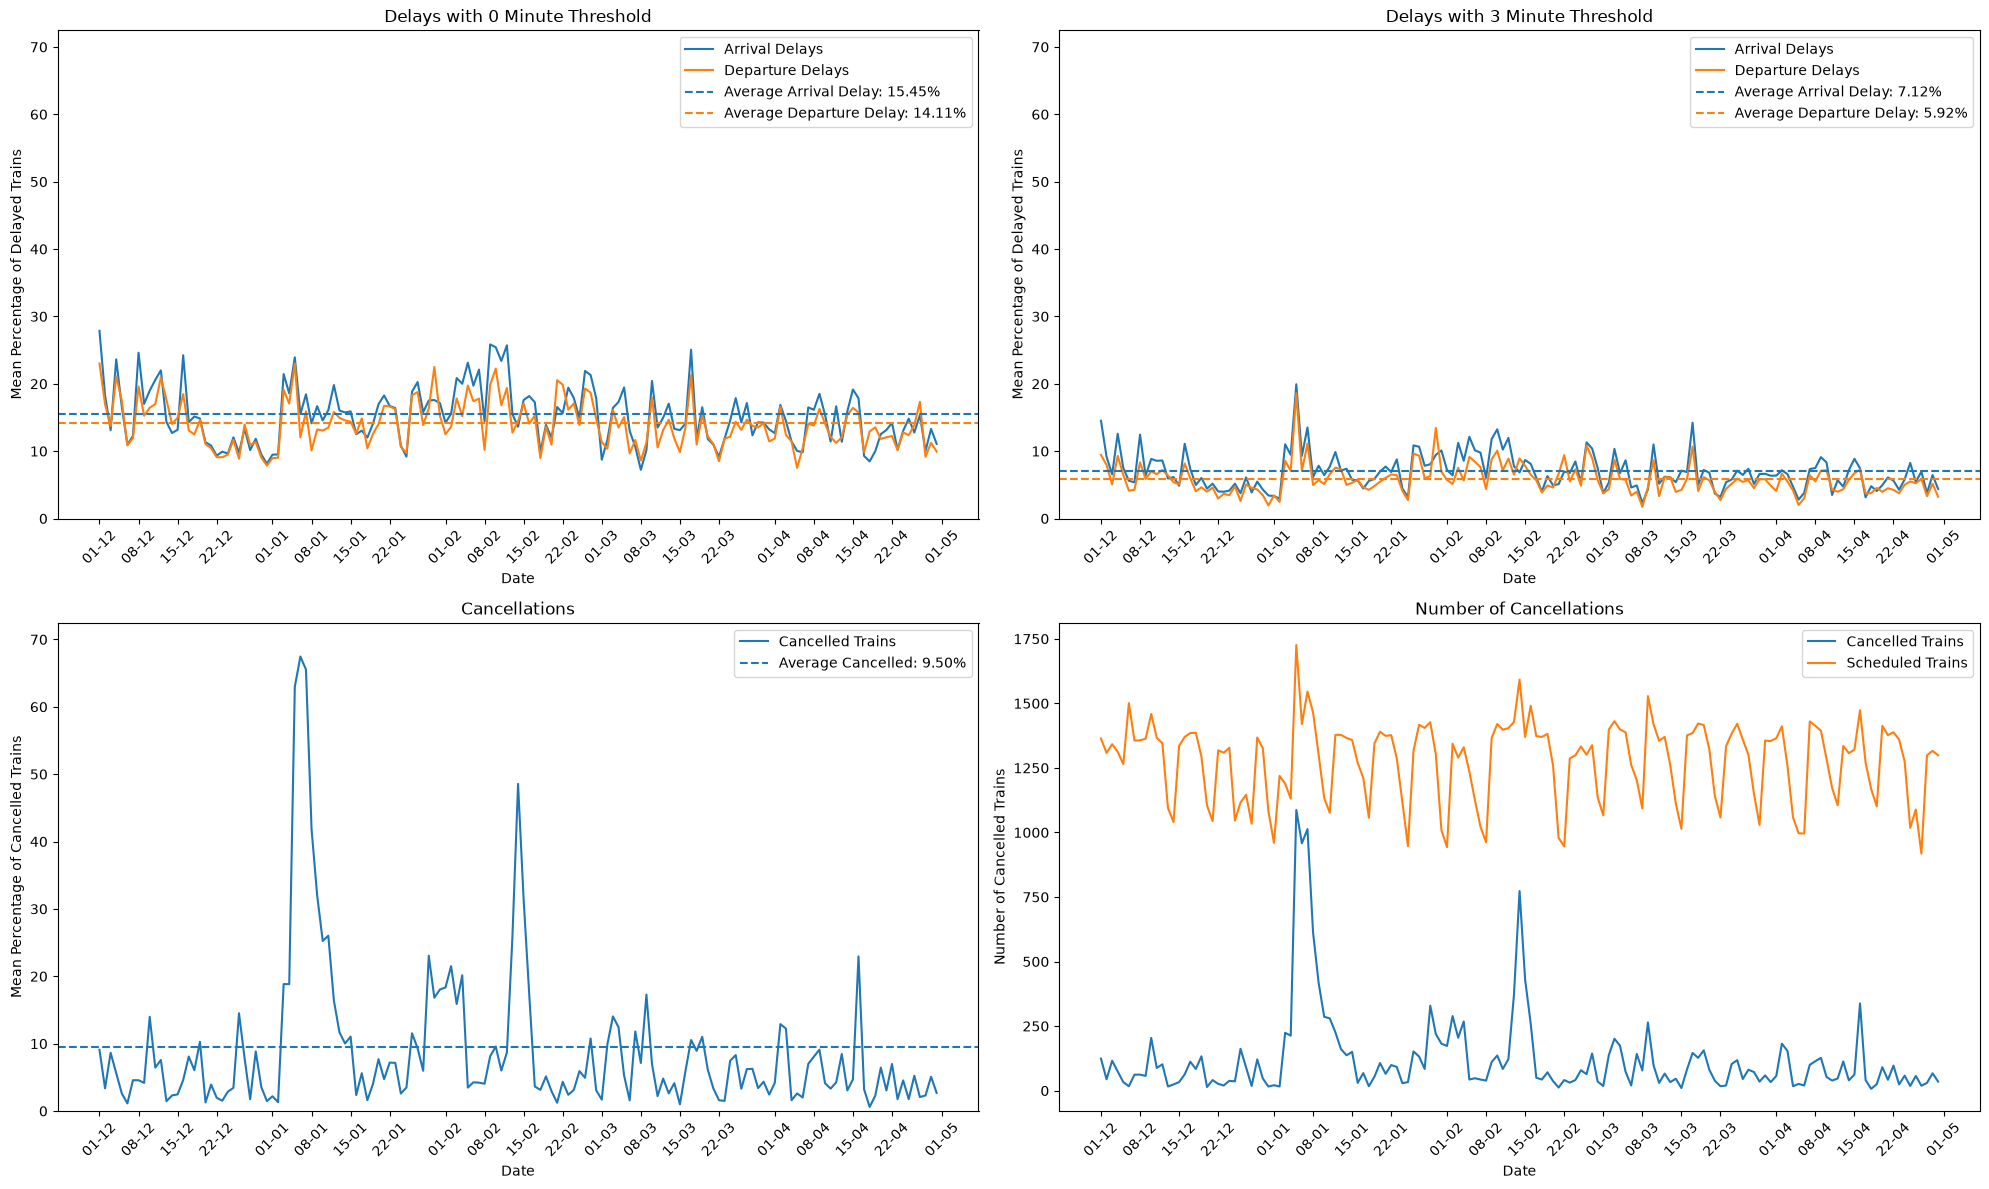

In [186]:
import matplotlib.dates as mdates 
daily_delay.index = pd.to_datetime(daily_delay.index) 
 
fig, ax = plt.subplots(2,2, figsize=(20, 12)) 
 
ax[0,0].plot(daily_delay.index, daily_delay['arrival_delayed'], label='Arrival Delays') 
ax[0,0].plot(daily_delay.index, daily_delay['departure_delayed'], label='Departure Delays') 
ax[0,0].axhline(average_arrival_delay, linestyle='--', color=ax[0,0].lines[0].get_color(), label=f'Average Arrival Delay: {average_arrival_delay:.2f}%') 
ax[0,0].axhline(average_departure_delay, linestyle='--', color=ax[0,0].lines[1].get_color(), label=f'Average Departure Delay: {average_departure_delay:.2f}%') 
ax[0,0].set_xlabel('Date') 
ax[0,0].set_ylabel('Mean Percentage of Delayed Trains') 
ax[0,0].set_title('Delays with 0 Minute Threshold') 
ax[0,0].legend() 
 
ax[0,1].plot(daily_delay.index, daily_delay['arrival_delayed_3'], label='Arrival Delays') 
ax[0,1].plot(daily_delay.index, daily_delay['departure_delayed_3'], label='Departure Delays') 
ax[0,1].axhline(average_arrival_delay_3, linestyle='--', color=ax[0,1].lines[0].get_color(), label=f'Average Arrival Delay: {average_arrival_delay_3:.2f}%') 
ax[0,1].axhline(average_departure_delay_3, linestyle='--', color=ax[0,1].lines[1].get_color(), label=f'Average Departure Delay: {average_departure_delay_3:.2f}%') 
ax[0,1].set_xlabel('Date') 
ax[0,1].set_ylabel('Mean Percentage of Delayed Trains') 
ax[0,1].set_title('Delays with 3 Minute Threshold') 
ax[0,1].legend() 
 
ax[1,0].plot(daily_delay.index, daily_delay['cancelled'], label='Cancelled Trains') 
ax[1,0].axhline(cancelled_percentage, linestyle='--', color=ax[1,0].lines[0].get_color(), label=f'Average Cancelled: {cancelled_percentage:.2f}%') 
ax[1,0].set_xlabel('Date') 
ax[1,0].set_ylabel('Mean Percentage of Cancelled Trains') 
ax[1,0].set_title('Cancellations') 
ax[1,0].legend() 

train['Date'] = pd.to_datetime(train['Date'])
daily_delay['cancelled_count'] = train.groupby('Date')['cancelled'].sum()
daily_delay['scheduled_count'] = train.groupby('Date').size()

ax[1,1].plot(daily_delay.index, daily_delay['cancelled_count'], label='Cancelled Trains')
ax[1,1].plot(daily_delay.index, daily_delay['scheduled_count'], label='Scheduled Trains')
ax[1,1].set_xlabel('Date') 
ax[1,1].set_ylabel('Number of Cancelled Trains') 
ax[1,1].set_title('Number of Cancellations') 
ax[1,1].legend() 
 
for a in ax.flat: 
    a.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=20, maxticks=30)) 
    a.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m')) 
    a.tick_params(axis='x', rotation=45) 

for a in ax.flat[:3]:
    a.set_ylim(0, max(daily_delay[
    ['arrival_delayed', 'departure_delayed',
     'arrival_delayed_3', 'departure_delayed_3',
     'cancelled']
    ].max()) + 5)

plt.tight_layout() 
plt.show()

In [ ]:
# Check for duplicates in dataset on specific day
day = train[train['Date'] == '2026-01-05'].reset_index(drop=True)

cols = ['train_id', 'scheduled_arrival', 'scheduled_departure']
duplicates = day[day.duplicated(cols, keep=False)].sort_values(cols)
duplicates

,Date,Type,train_id,actual_arrival,arr_delay,arr_cancelled,actual_departure,dep_delay,dep_cancelled,scheduled_arrival,scheduled_departure,arrival_delayed,departure_delayed,arrival_delayed_3,departure_delayed_3,cancelled


- Analyse train delays (amount, spread) over time
- Analyse train cancellations over time
- Classify primary and secondary delays (or a variant on it on incoming vs outgoing delays)
- Check if input delay == output delay always?

Notes:
- Current max delays are max delay over all stops for the trajectory
- Check if Keeping NaNs or creating 3 dfs for in, out and through?

#### Data visualization

#### Data manipulation & Analysis